# EDA and first step of feature selection

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
data_dir = Path('../../data')
X_train = pd.read_csv(data_dir / 'x_train.txt', sep=' ')
y_train = pd.read_csv(data_dir / 'y_train.txt', sep=' ').values.ravel()
n_old, p_old = X_train.shape

X_train = X_train.T.drop_duplicates().T
X_train.drop_duplicates(inplace=True)
n, p = X_train.shape
# duplicate columns: V175 = V32, V416 = V160

In [3]:
print(f"Shape: n = {n}, p = {p}")
print(f"Class 1: {np.mean(y_train) * 100:0.2f}%")
print(f"Column types: {np.unique(X_train.dtypes)}")
print(f"Missing data: {np.sum(np.sum(X_train.isna(), axis=1), axis=0)}")
print(f"Column duplicates: {p_old - p}, row duplicates: {n_old - n}")

Shape: n = 5000, p = 498
Class 1: 49.76%
Column types: [dtype('float64')]
Missing data: 0
Column duplicates: 2, row duplicates: 0


In [4]:
X_train.describe()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V491,V492,V493,V494,V495,V496,V497,V498,V499,V500
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,...,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,0.500233,0.500273,10.048039,0.495947,0.025057,0.496769,0.498385,0.498027,0.493844,-0.022705,...,-0.005252,0.503225,0.500664,0.005485,9.983796,0.014929,0.495957,9.953891,-0.017337,0.497873
std,0.286156,0.285742,4.582863,0.286356,2.480097,0.292497,0.290257,0.291401,0.289450,0.993465,...,1.000026,0.286948,0.291534,1.004822,4.487236,0.991845,0.290911,4.435534,0.990030,0.288636
min,0.000195,0.000107,0.958113,0.000026,-8.803497,0.000116,0.000075,0.000060,0.000095,-3.693892,...,-3.750717,0.000151,0.000105,-3.587849,0.986320,-3.358077,0.000163,0.940390,-3.381385,0.000106
25%,0.254151,0.247001,6.771772,0.248746,-1.613801,0.241448,0.247769,0.240210,0.242509,-0.712855,...,-0.665776,0.256773,0.245910,-0.676383,6.716957,-0.658023,0.243473,6.685453,-0.675339,0.250572
50%,0.506632,0.502785,9.310201,0.500593,0.022467,0.494284,0.498828,0.498829,0.488783,-0.019341,...,0.001532,0.504650,0.499564,0.009176,9.370211,0.016059,0.500924,9.286676,-0.012790,0.497029
75%,0.743107,0.746211,12.658089,0.741587,1.693679,0.756912,0.748557,0.744075,0.748062,0.651148,...,0.646321,0.748965,0.756052,0.683569,12.524212,0.696753,0.747700,12.458401,0.662880,0.746191
max,0.999599,0.999994,33.537836,0.999796,9.441396,0.999849,0.999791,0.999605,0.999690,3.145788,...,3.861070,0.999976,0.999963,3.789411,39.996344,4.547909,0.999711,30.002210,3.460326,0.999529


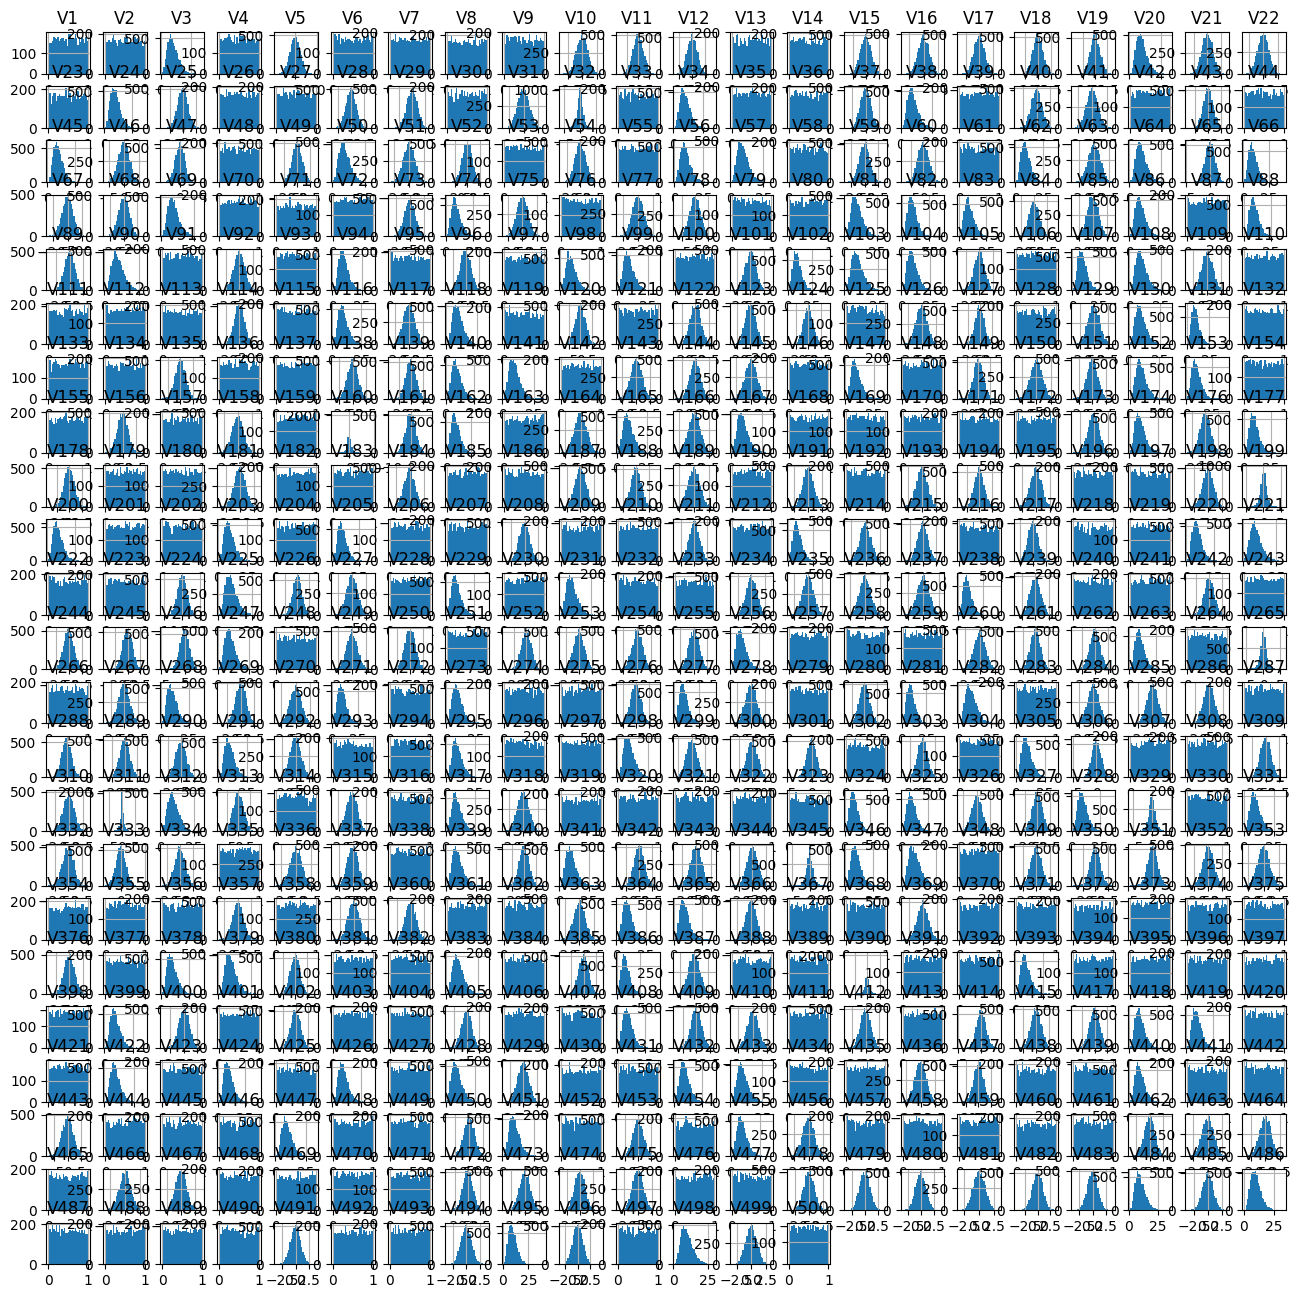

In [5]:
X_train.hist(figsize=(16, 16), bins=30)
plt.show()
# all predictors are look like either normal, gamma (skewed to the right) or uniform distribution ?
# hard to notice any anomalies
# no constant features

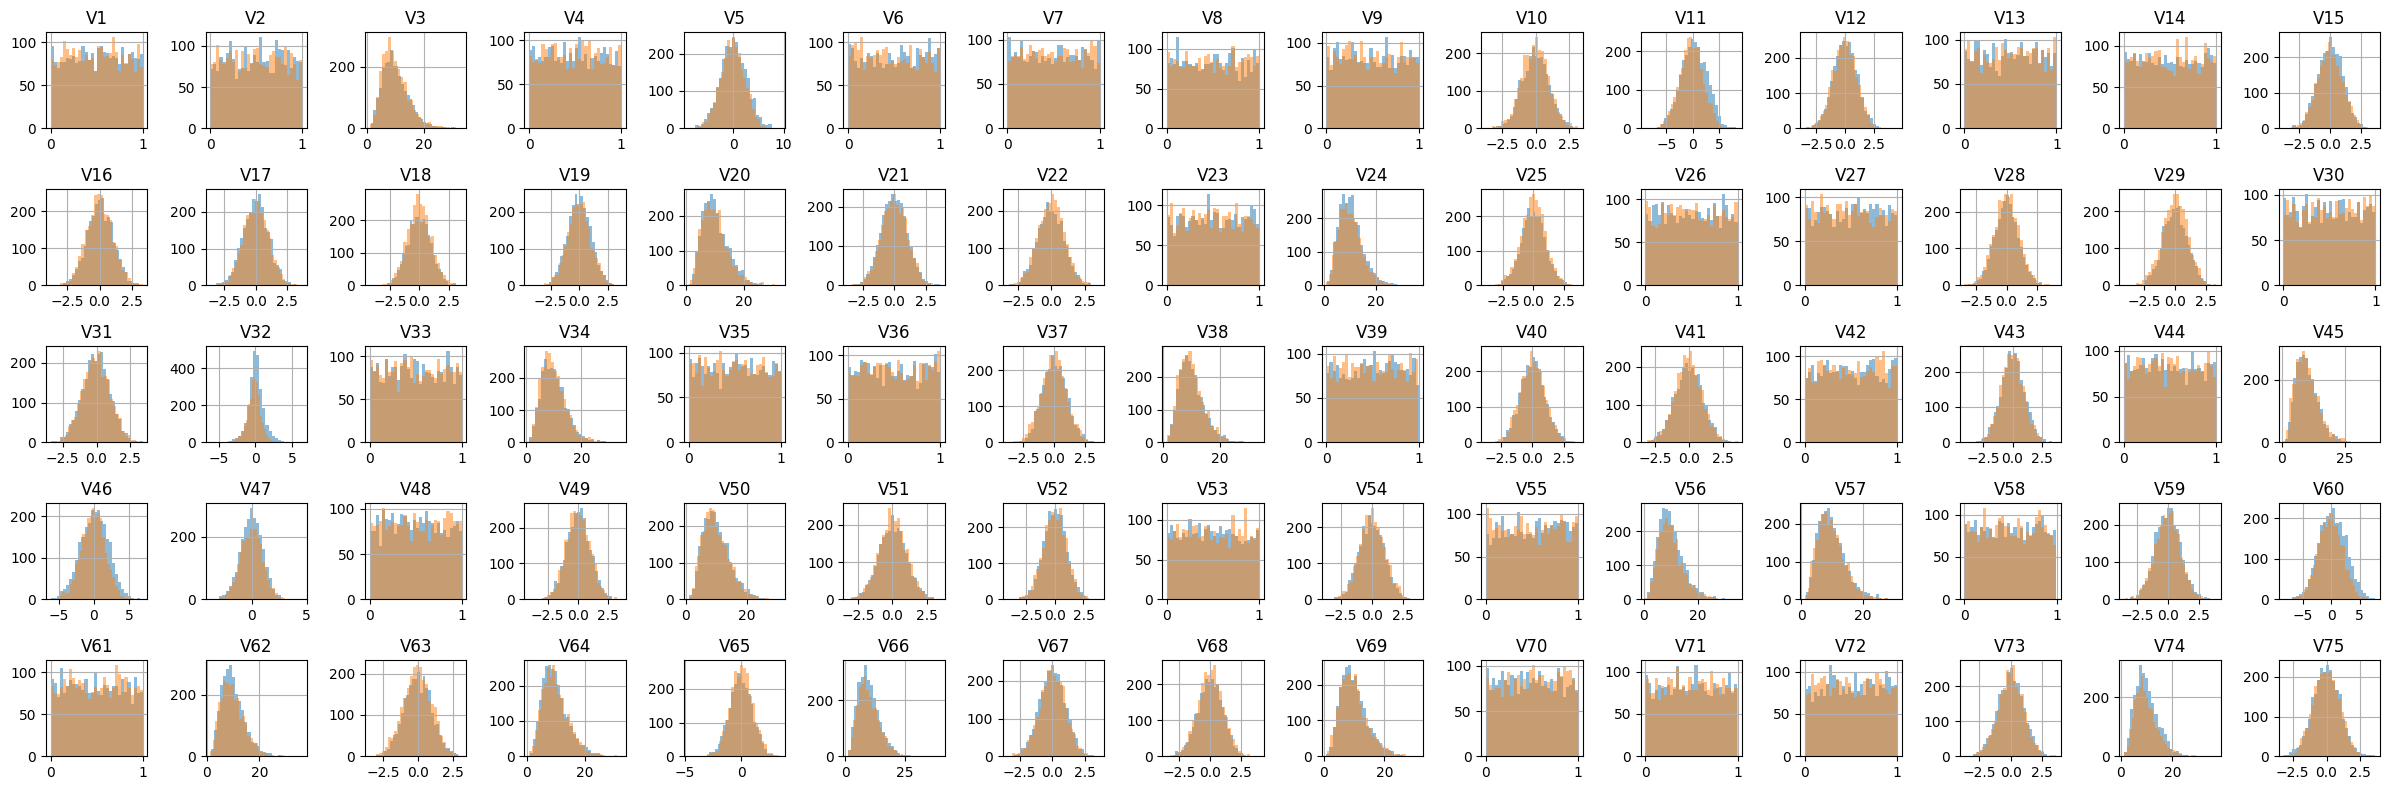

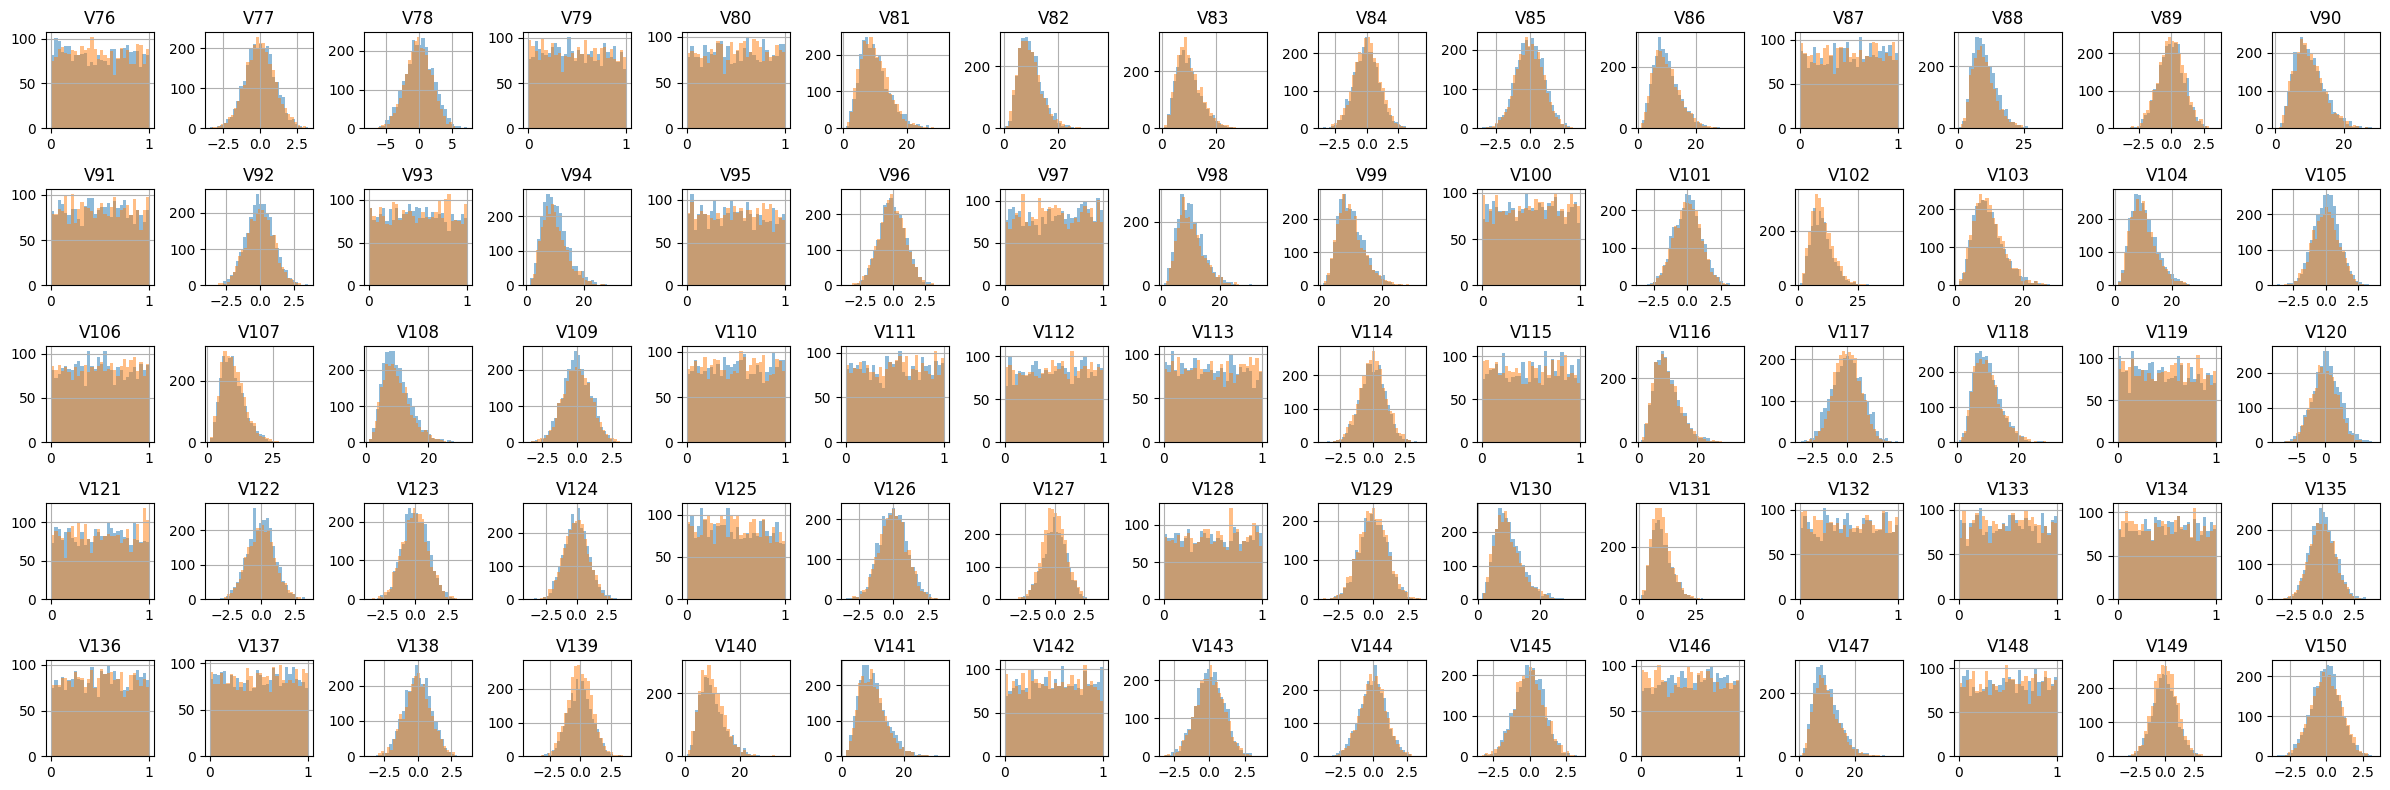

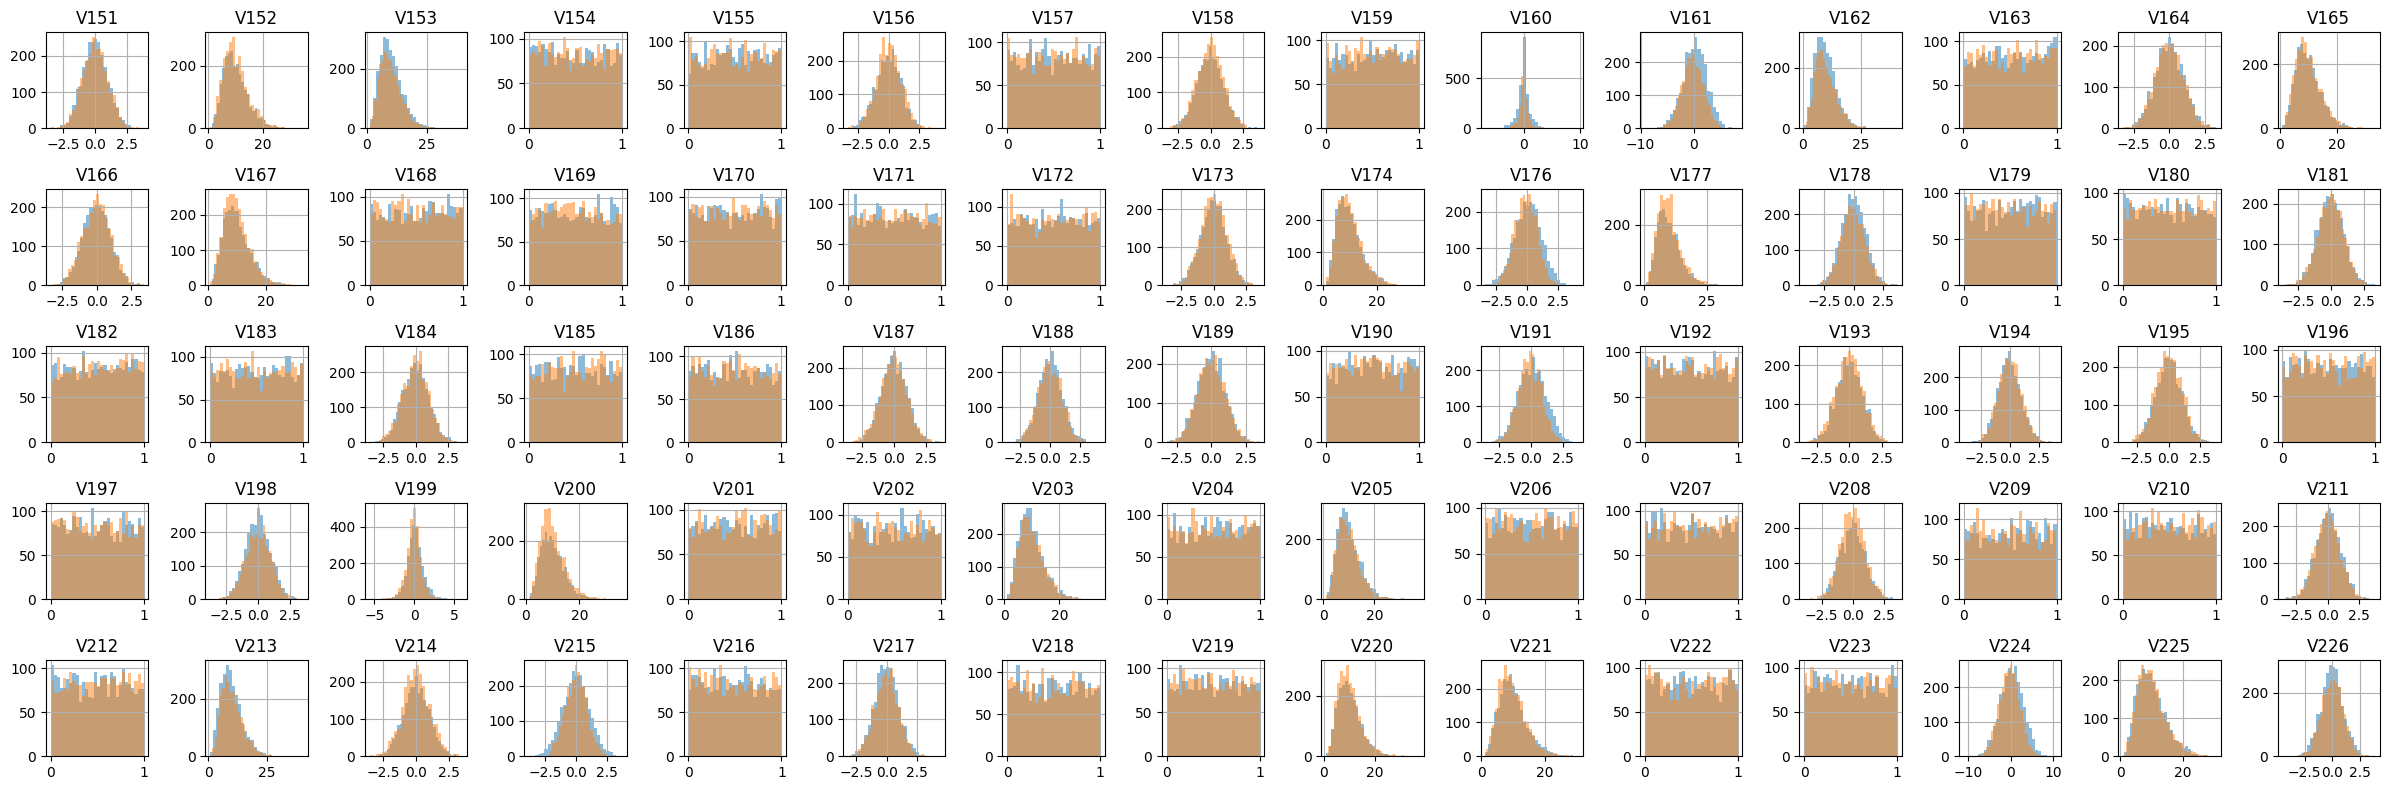

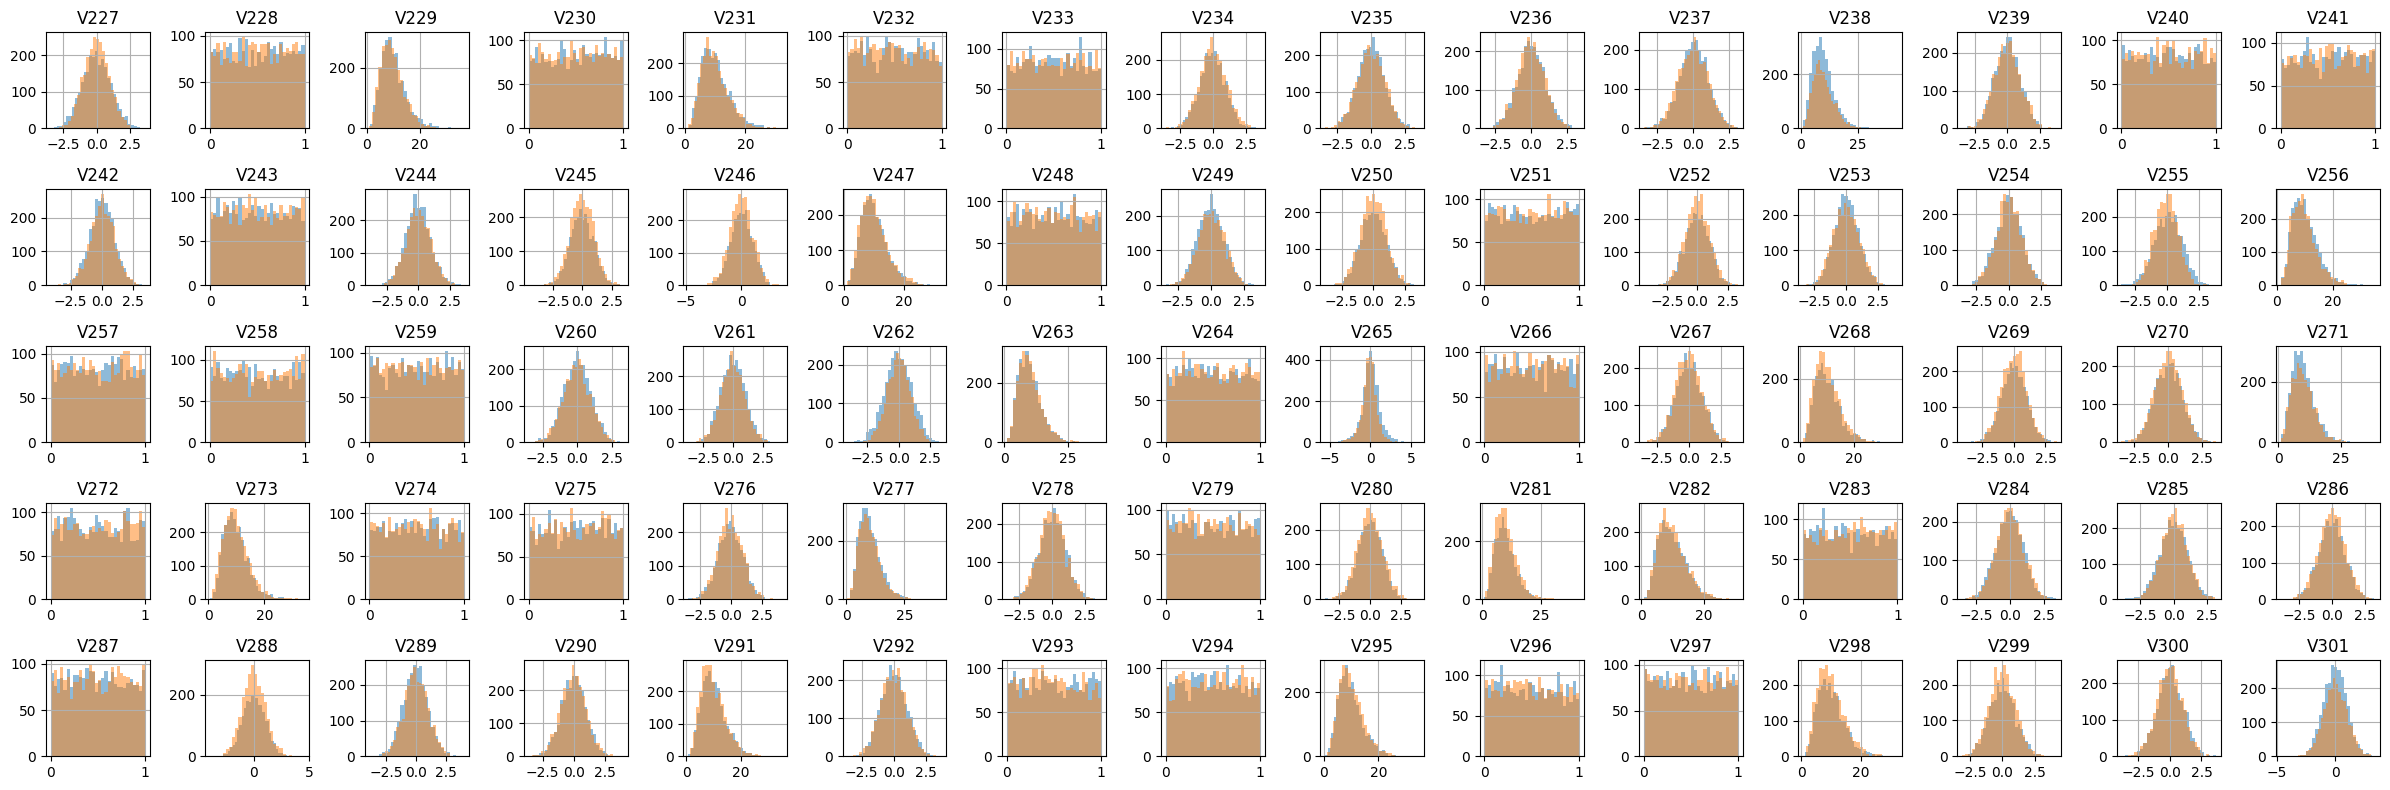

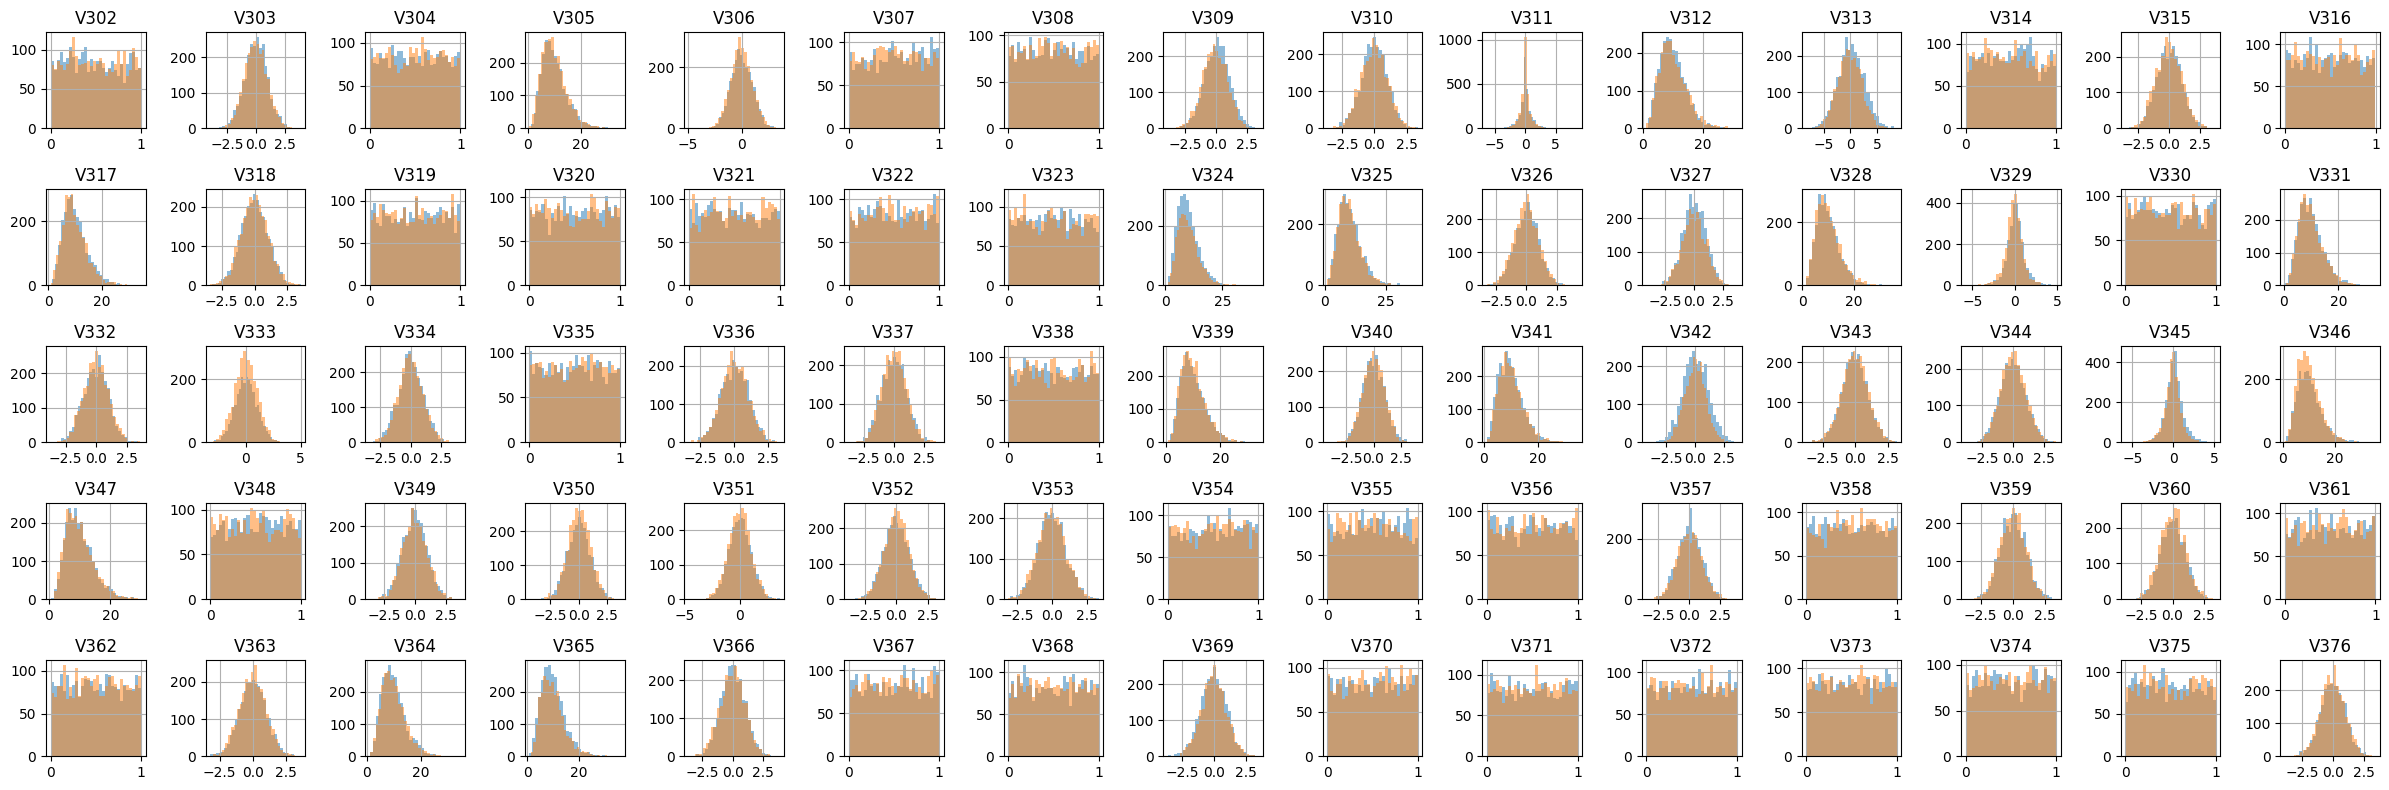

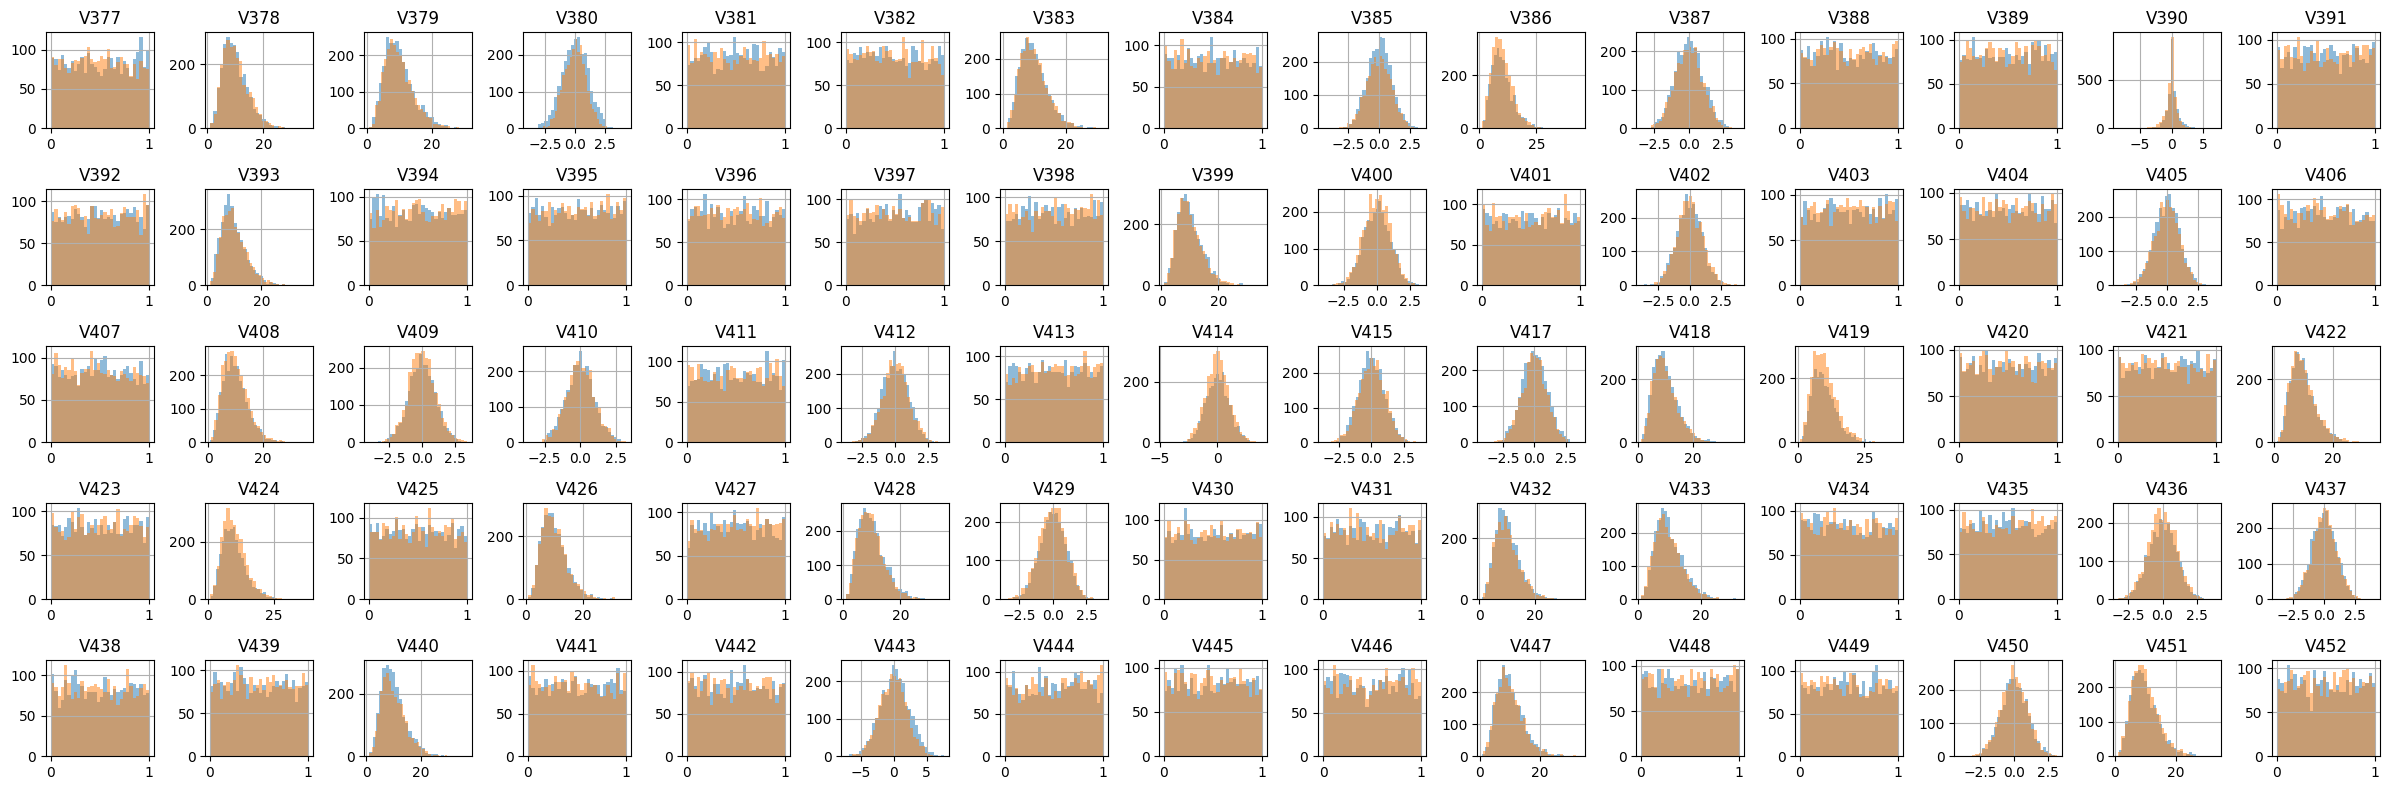

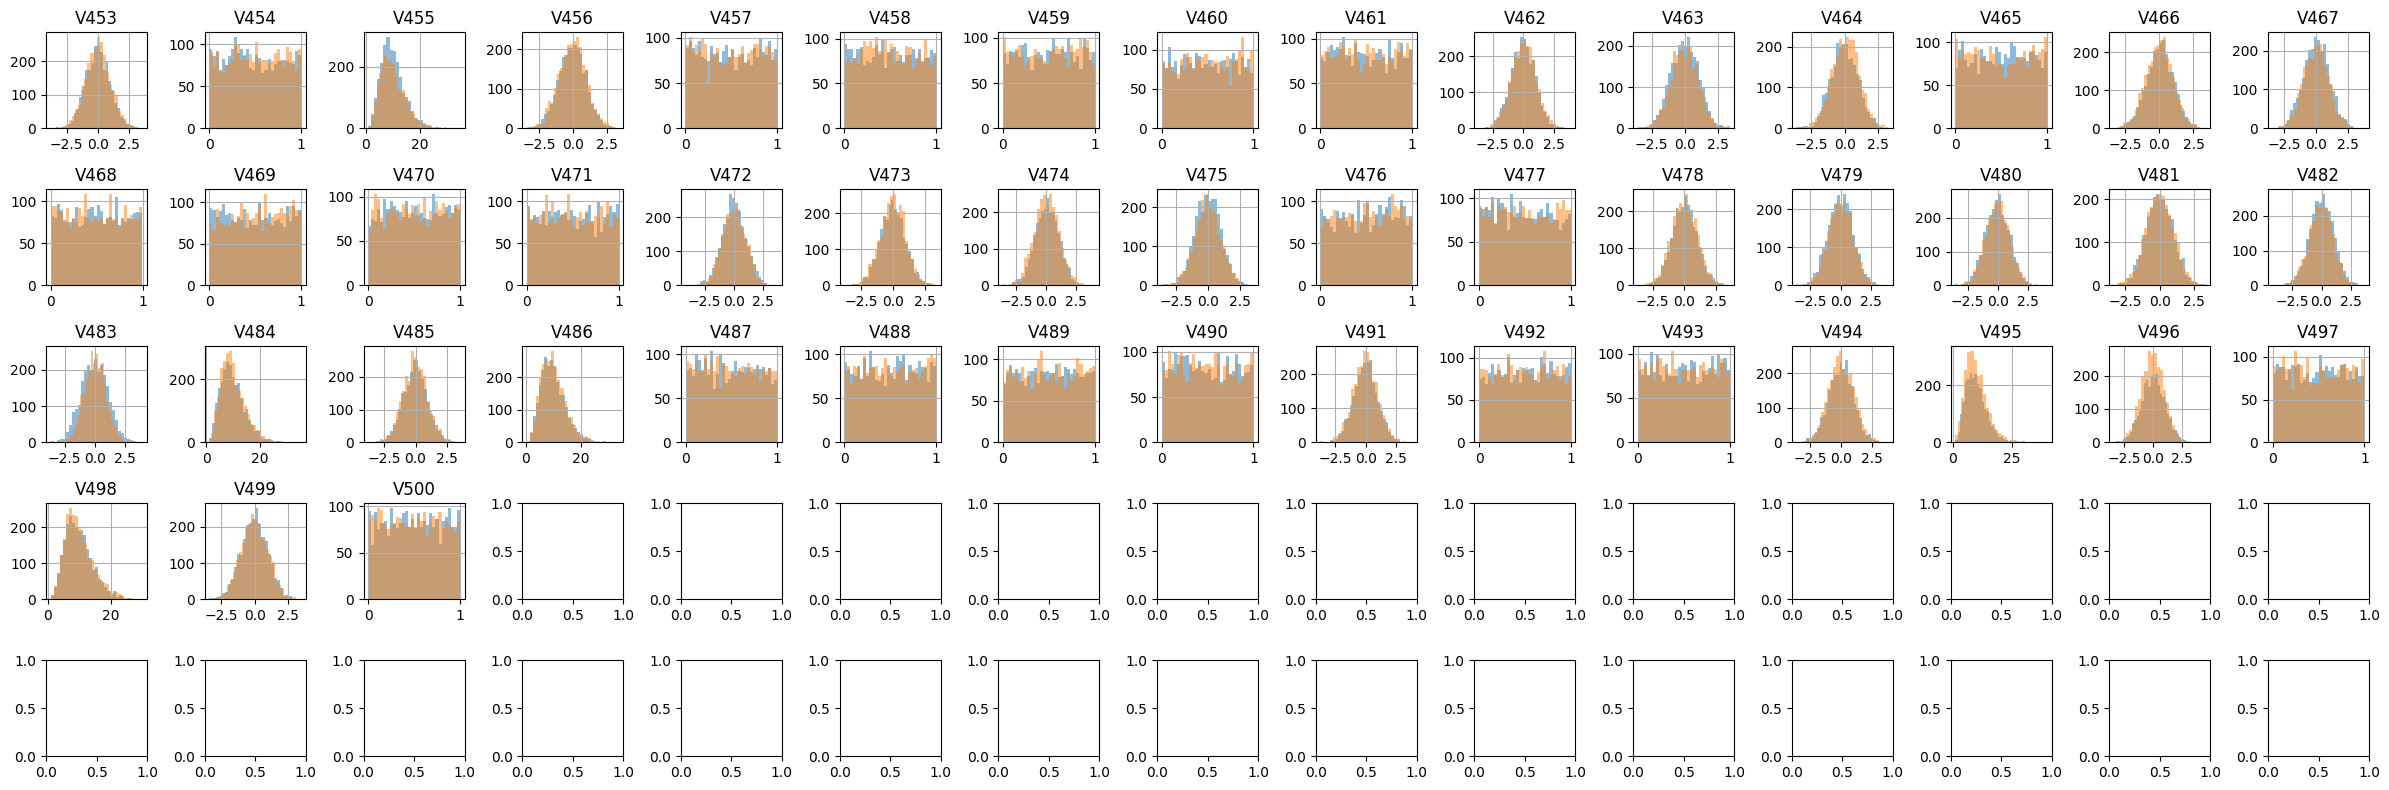

In [6]:
data = pd.concat([X_train, pd.DataFrame(y_train, columns=['y'])], axis=1)
features = data.columns.drop('y')
batch_size = 5*15

for start_idx in range(0, len(features), batch_size):
    batch = features[start_idx : start_idx + batch_size]
    fig, axes = plt.subplots(nrows=5, ncols=15, figsize=(24, 8))
    axes = axes.flatten()
    
    for i, col in enumerate(batch):
        data[data['y'] == 1][col].hist(alpha=0.5, bins=30, ax=axes[i], label='Class 1')
        data[data['y'] == 0][col].hist(alpha=0.5, bins=30, ax=axes[i], label='Class 0')
        axes[i].set_title(col)
        
    plt.tight_layout()
    plt.show()

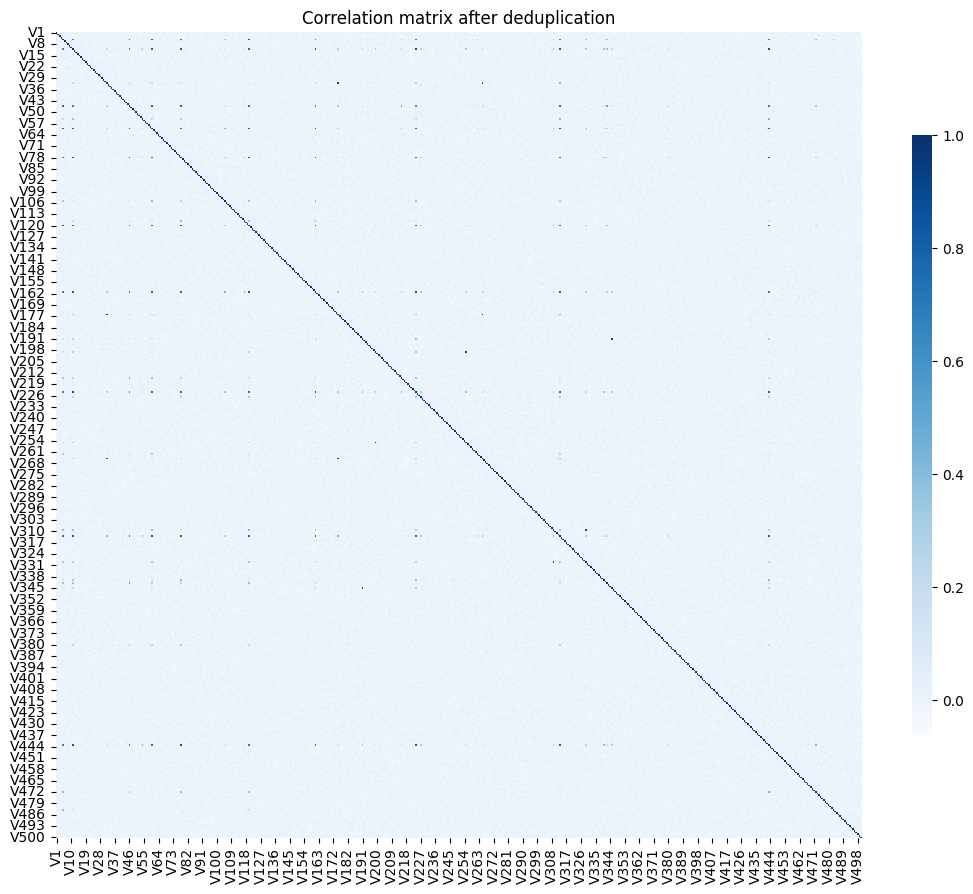

In [7]:
corr_matrix = X_train.corr()
fig, ax = plt.subplots(figsize=(13, 13))
sns.heatmap(
    corr_matrix,
    square=True,
    cmap="Blues",
    cbar_kws={"shrink": 0.6, "aspect": 30})
plt.title("Correlation matrix after deduplication")
plt.show()

# intersting grid-like pattern

## First step of feature selection

In [8]:
# columns with abs(correlation) > 0.8
upper = abs(corr_matrix).where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

cols = []
high_corr_pairs = []
for row in upper.index:
    for col in upper.columns:
        if upper.loc[row, col] > 0.8:
            high_corr_pairs.append((col, row, upper.loc[row, col]))
            cols.append(col)
            cols.append(row)
cols = np.unique(cols)

for elem in high_corr_pairs:
    print(elem)

# VERY interesting results!
# these variables create 5 clusters

('V60', 'V5', np.float64(0.8213618338158666))
('V78', 'V11', np.float64(0.8076392656171207))
('V224', 'V11', np.float64(0.8807696253441699))
('V313', 'V11', np.float64(0.8097464730132935))
('V443', 'V11', np.float64(0.8447086696596476))
('V176', 'V32', np.float64(0.9152183464604331))
('V265', 'V32', np.float64(0.8357556535717495))
('V60', 'V46', np.float64(0.8285751892361178))
('V313', 'V60', np.float64(0.8851603803348861))
('V120', 'V78', np.float64(0.8352581816575597))
('V443', 'V78', np.float64(0.8825319202119688))
('V161', 'V120', np.float64(0.84175947598537))
('V224', 'V161', np.float64(0.8710001292081314))
('V313', 'V161', np.float64(0.8039000893985798))
('V265', 'V176', np.float64(0.9121312557222008))
('V345', 'V191', np.float64(0.912227974718394))
('V255', 'V199', np.float64(0.9103210476984752))
('V443', 'V224', np.float64(0.800273796436642))
('V329', 'V309', np.float64(0.9120051194651927))


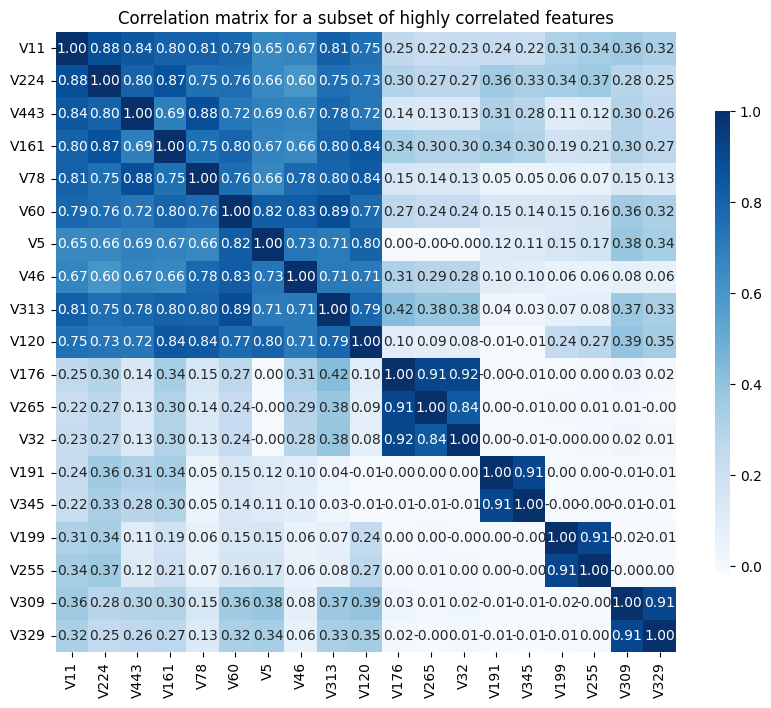

In [9]:
c = ['V11', 'V224', 'V443', 'V161', 'V78', 'V60', 'V5', 'V46', 'V313', 'V120', 'V176', 'V265', 'V32', 'V191', 'V345', 'V199', 'V255', 'V309', 'V329']

a = corr_matrix.loc[c, c]
fig, ax = plt.subplots(figsize=(10, 10))
sns.heatmap(
    a,
    annot=True,
    fmt=".2f",
    square=True,
    # vmin=0.6,
    cmap="Blues",
    cbar_kws={"shrink": 0.6, "aspect": 30},
)
plt.title("Correlation matrix for a subset of highly correlated features")
plt.show()

# here we can see clearly the 5 groups
# for the 4 small grous we will keep one variable and then we will think what to do with the big group

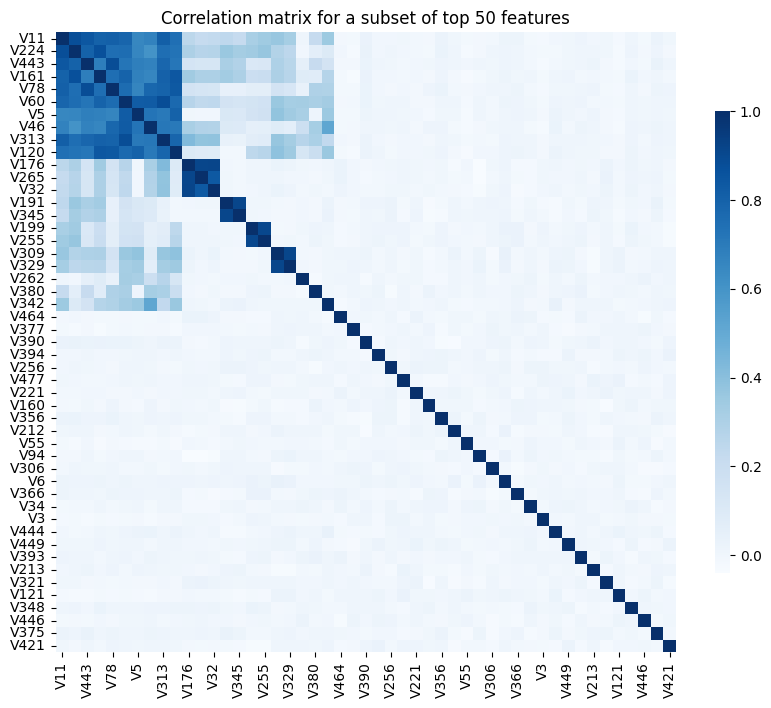

In [18]:
d = ['V11', 'V224', 'V443', 'V161', 'V78', 'V60', 'V5', 'V46', 'V313', 'V120', 'V176', 'V265', 'V32', 'V191', 'V345', 'V199', 'V255', 'V309', 'V329', 'V262', 'V380', 'V342', 'V464', 'V377', 'V390', 'V394', 'V256', 'V477', 'V221', 'V160', 'V356', 'V212', 'V55', 'V94', 'V306', 'V6', 'V366', 'V34', 'V3', 'V444', 'V449', 'V393', 'V213', 'V321', 'V121', 'V348', 'V446', 'V375', 'V421']
a = corr_matrix.loc[d, d]
fig, ax = plt.subplots(figsize=(10, 10))
sns.heatmap(
    a,
    # annot=True,
    fmt=".2f",
    square=True,
    # vmin=0.6,
    cmap="Blues",
    cbar_kws={"shrink": 0.6, "aspect": 30},
)
plt.title("Correlation matrix for a subset of top 50 features")
plt.show()

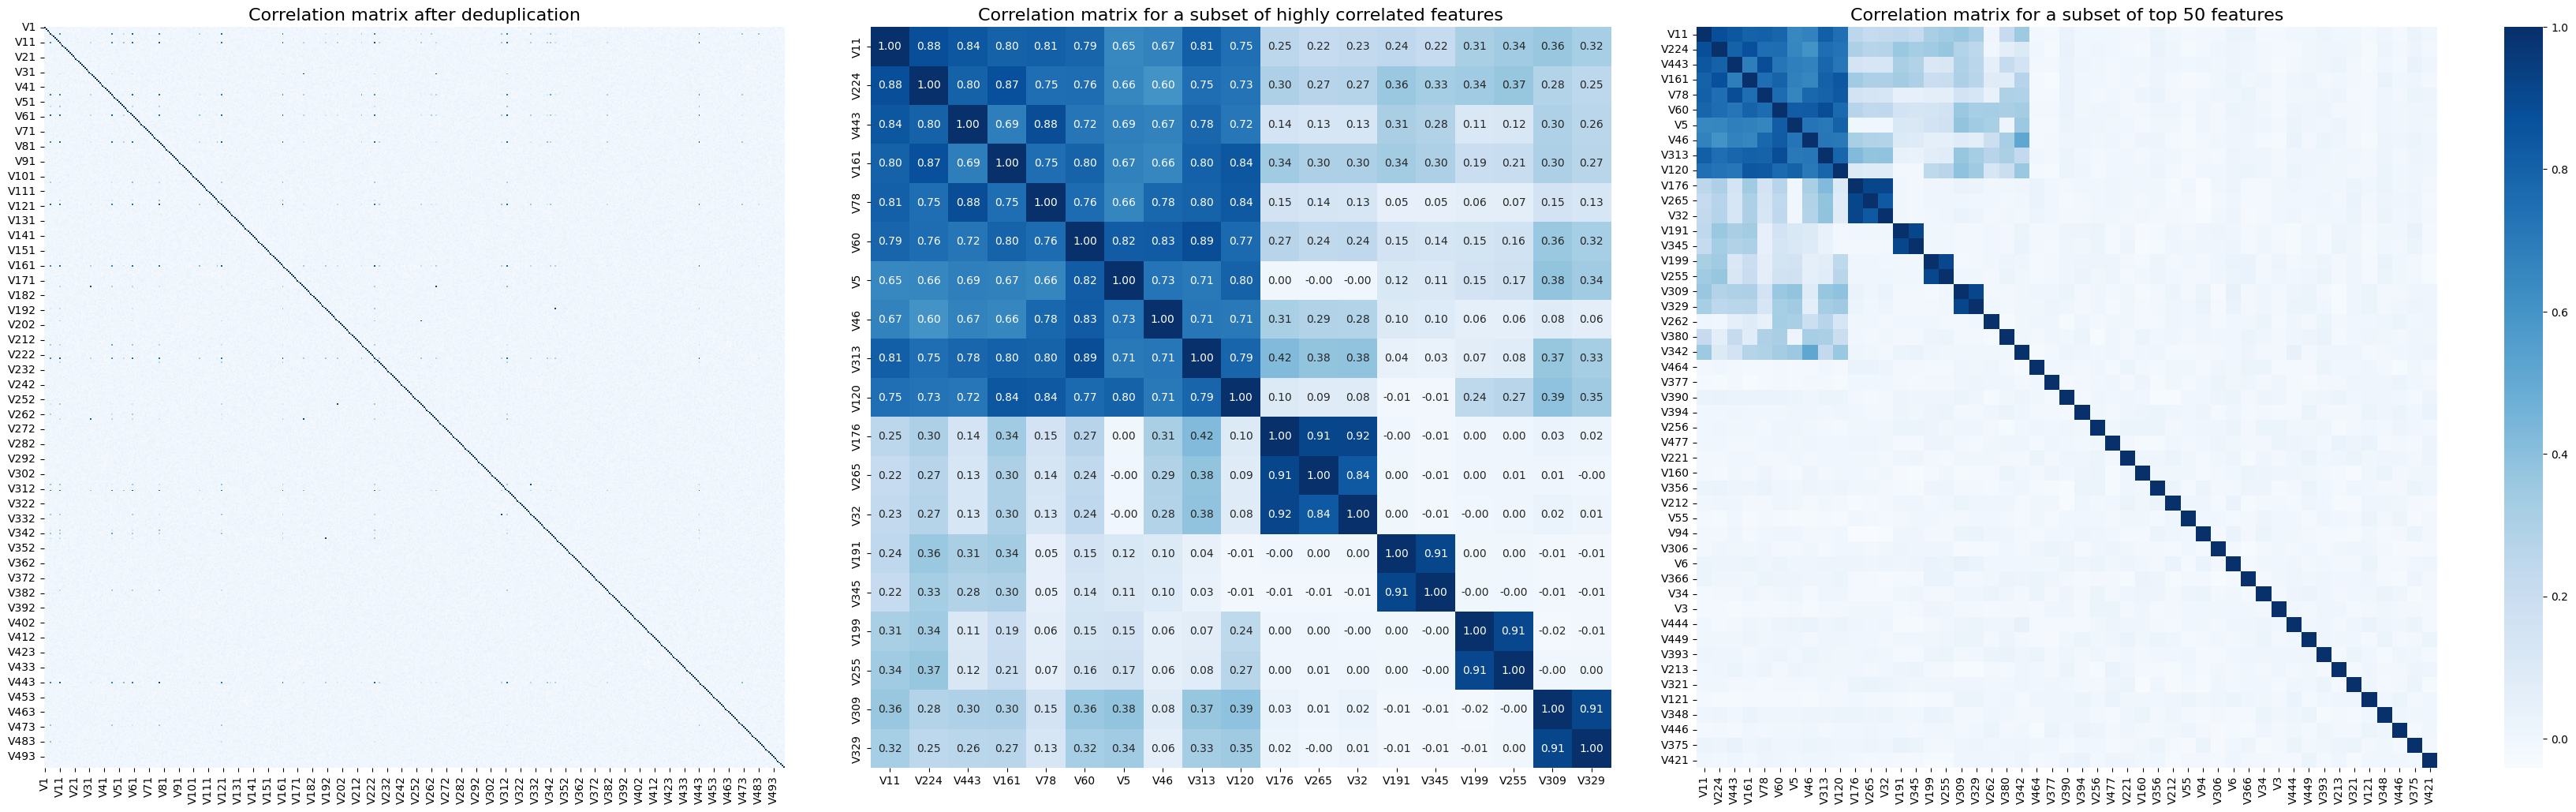

In [11]:
c = ['V11', 'V224', 'V443', 'V161', 'V78', 'V60', 'V5', 'V46', 'V313', 'V120', 'V176', 'V265', 'V32', 'V191', 'V345', 'V199', 'V255', 'V309', 'V329']
d = ['V11', 'V224', 'V443', 'V161', 'V78', 'V60', 'V5', 'V46', 'V313', 'V120', 'V176', 'V265', 'V32', 'V191', 'V345', 'V199', 'V255', 'V309', 'V329', 'V262', 'V380', 'V342', 'V464', 'V377', 'V390', 'V394', 'V256', 'V477', 'V221', 'V160', 'V356', 'V212', 'V55', 'V94', 'V306', 'V6', 'V366', 'V34', 'V3', 'V444', 'V449', 'V393', 'V213', 'V321', 'V121', 'V348', 'V446', 'V375', 'V421']
a1 = corr_matrix.loc[c, c]
a2 = corr_matrix.loc[d, d]

vmin = a2.min().min()

fig, axes = plt.subplots(
    1, 4, figsize=(33, 10), gridspec_kw={"width_ratios": [1, 1, 1, 0.05]}
)

sns.heatmap(
    corr_matrix,
    ax=axes[0],
    square=True,
    cmap="Blues",
    vmin=vmin,
    vmax=1,
    cbar=False,
)
axes[0].set_title("Correlation matrix after deduplication", fontsize=16)

sns.heatmap(
    a1,
    ax=axes[1],
    annot=True,
    fmt=".2f",
    cmap="Blues",
    vmin=vmin,
    vmax=1,
    square=True,
    cbar=False,
)
axes[1].set_title("Correlation matrix for a subset of highly correlated features", fontsize=16)

sns.heatmap(
    a2,
    ax=axes[2],
    cmap="Blues",
    vmin=vmin,
    vmax=1,
    square=True,
    cbar=True,
    cbar_ax=axes[3],
)
axes[2].set_title("Correlation matrix for a subset of top 50 features", fontsize=16)

plt.tight_layout()
plt.show()

In [ ]:
# aggregated results of 4 differnt approaches to evaluate feature importnance 
df = pd.read_csv("feature_importance_rank.csv")

# rank of the highly correlated varaivbles
df[df["variable"].isin(cols)][["variable", "overall_rank"]]

,variable,overall_rank
0,V11,1
1,V176,2
2,V255,3
3,V313,4
4,V191,5
5,V265,6
6,V224,7
7,V5,8
8,V443,9
9,V161,10


1. big group <br>
    maybe v11 (rank 1), v313 (rank 4) or v224 (rank 7) - test during cv <br>
    
1. group 176, 265, 32 <br> 
    ranks: 2, 6, 19<br> 
    keep: 176<br>
2. group 191, 345<br>
    ranks: 6, 14<br>
    keep: 191

3. group 199, 255<br>
    ranks: 17, 3<br>
    keep: 255

4. group 309, 329<br>
    ranks: 13, 35<br>
    keep: 309

In [13]:
keep = ['V11', 'V313', 'V224', 'V176', 'V191', 'V255', 'V309']
drop = list(set(cols) - set(keep))
top40 = list(df["variable"].head(40))
selected = list(set(top40) - set(drop))
print(f"{len(selected)} predictors selected for further examination and model evaluation:")
print(selected)

30 predictors selected for further examination and model evaluation:
['V394', 'V221', 'V380', 'V55', 'V212', 'V356', 'V366', 'V191', 'V306', 'V477', 'V390', 'V176', 'V377', 'V6', 'V309', 'V34', 'V160', 'V444', 'V175', 'V449', 'V224', 'V255', 'V11', 'V262', 'V416', 'V313', 'V3', 'V464', 'V94', 'V256']
